In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [3]:
# ===========================================
# MODULE 1: IMPORTING DATASET
# ===========================================

#Import the data
df = pd.read_csv("../../data/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [4]:
df.drop(columns=['Id'], inplace=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
# ===============================
# MODULE 2: SPLITTING DATA
# ===============================

from sklearn.model_selection import train_test_split

X = df.drop('quality', axis=1) # axis = 1 (for column)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of Training set X : {X_train.shape}")
print(f"Shape of Test set X : {X_test.shape}")


Shape of Training set X : (914, 11)
Shape of Test set X : (229, 11)


## Theory: Robust Scaling (`RobustScaler`)

**What it does**

`RobustScaler` rescales each feature using statistics that are **robust to outliers** — the **median** and the **Interquartile Range (IQR)** — instead of the min/max used by `MinMaxScaler` or the mean/std used by `StandardScaler`.

$$
X_{scaled} = \frac{X - \text{median}(X)}{IQR(X)} = \frac{X - Q_2}{Q_3 - Q_1}
$$

- `Q1` (25th percentile) and `Q3` (75th percentile) are computed **per feature, from the training data only**.
- `IQR = Q3 - Q1` captures the spread of the "middle 50%" of the data — the region least affected by extreme values.
- Unlike Min-Max scaling, the output is **not bounded** to a fixed range like [0, 1]. Values can be negative, and there's no fixed upper bound — the median maps to 0, and typical values fall roughly in [-1, 1], but extreme values can land far outside that.

**Why it's "robust"**

The median and IQR are **resistant to outliers** by construction — a single extreme value (or even several) barely shifts the median of a large dataset, and doesn't affect Q1/Q3 unless it's extreme enough to breach the 25th/75th percentile boundaries themselves. Compare this to `MinMaxScaler`, where a *single* outlier directly redefines `X_min` or `X_max` for the entire feature.


In [6]:
# =========================================
# MODULE 3: Robust Scaling (RobustScaler)
# =========================================


from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# fit the scaler to train set, it will learn median and IQR
scaler.fit(X_train)

# Transform train and test sets 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converting to pandas data frame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)



**`fit` vs `transform` — same rule as before**

Just like `MinMaxScaler`, you must:
1. Split data first.
2. `fit()` the scaler on `X_train` only — it learns median and IQR from training data.
3. `transform()` both `X_train` and `X_test` using those learned parameters.

Fitting on the full dataset (or on test data) would leak test-set distribution info into training — same data leakage concern as before.

**When to prefer RobustScaler over MinMaxScaler / StandardScaler**

- Your data has outliers you don't want to remove but also don't want dominating the scale.
- You still want scale-invariance for distance/gradient-based models, but without a single extreme row distorting everything else.

In [7]:
# Info Of Data
# Before Scaling 
X_train.describe().round(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0
mean,8.3,0.5,0.3,2.5,0.1,15.7,45.8,1.0,3.3,0.7,10.4
std,1.7,0.2,0.2,1.3,0.0,10.2,31.9,0.0,0.2,0.2,1.1
min,4.6,0.1,0.0,0.9,0.0,1.0,6.0,1.0,2.7,0.3,8.4
25%,7.1,0.4,0.1,1.9,0.1,7.0,21.0,1.0,3.2,0.6,9.5
50%,7.9,0.5,0.2,2.2,0.1,13.0,38.0,1.0,3.3,0.6,10.2
75%,9.0,0.6,0.4,2.6,0.1,21.0,62.0,1.0,3.4,0.7,11.2
max,15.6,1.6,1.0,15.5,0.6,68.0,278.0,1.0,4.0,2.0,14.0


In [8]:
# After scaling 
X_train_scaled.describe().round(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0
mean,0.2,0.0,0.0,0.5,0.4,0.2,0.2,0.0,0.0,0.2,0.1
std,0.9,0.7,0.6,1.9,2.4,0.7,0.8,0.8,0.8,1.0,0.6
min,-1.7,-1.7,-0.8,-1.9,-3.3,-0.9,-0.8,-2.9,-3.0,-1.7,-1.1
25%,-0.4,-0.5,-0.5,-0.4,-0.4,-0.4,-0.4,-0.5,-0.5,-0.4,-0.4
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.6,0.5,0.5,0.6,0.6,0.6,0.6,0.5,0.5,0.6,0.6
max,4.1,4.4,2.3,19.0,26.7,3.9,5.9,2.9,3.7,8.1,2.2


## Result Analysis: `describe()` Before vs After Robust Scaling

**What the output shows**

Summary statistics for all 11 features, before scaling (raw units) and after applying `RobustScaler`.

**Observations**

- **Median (50%) is exactly 0.0 for every single feature after scaling.** This is the direct, verifiable proof of the theory: `RobustScaler` centers data on the **median**, not the mean (as `StandardScaler` would) and not the minimum (as `MinMaxScaler` would). Before scaling, medians varied per feature (e.g., `pH` median 3.3, `chlorides` median 0.1) — after scaling, they're all uniformly 0.

- **25th and 75th percentiles are ~ -0.4 to -0.5 and ~0.5 to 0.6 respectively, across almost every feature.** This is expected — by definition, `RobustScaler` divides by the IQR (`Q3 - Q1`), so the scaled Q1 and Q3 will always sit close to -0.5 and +0.5 regardless of the feature's original units. This is the "robust" equivalent of Min-Max squashing everything into a fixed [0,1] band — except here it's the **middle 50% of data** that gets standardized in width, not the full range.

- **No fixed range — min/max vary wildly per feature, unlike MinMaxScaler.** This is the key difference to notice:
  - `fixed acidity`: min -1.7, max 4.1
  - `chlorides`: min -3.3, max 26.7
  - `sulphates`: min -1.7, max 8.1
  - `density`: min -2.9, max 5.9
  
  With `MinMaxScaler`, every feature's min/max would be exactly 0/1 by construction. Here, the min/max are **whatever's left over** after centering on median and scaling by IQR — features with more extreme outliers relative to their typical spread (like `chlorides` and `sulphates`) end up with much larger scaled max values, because those outliers are far from the IQR-defined "normal" range and get proportionally stretched. This is expected and correct: RobustScaler doesn't try to force outliers into a bounded range — it only ensures the *typical* (non-outlier) data is scaled consistently.

- **Std after scaling is no longer ~1 like it would be with StandardScaler**, and varies per feature (0.6 to 2.4). This is normal for `RobustScaler` — it doesn't target unit variance; it targets unit IQR. Features like `chlorides` (std 2.4) have a long right tail relative to their IQR, so much of their spread lives outside the "robust" central scaling window.

**Conclusion**

The `describe()` output confirms both theoretical properties of `RobustScaler`:
1. **Centering on median** — every feature's 50th percentile is exactly 0 after scaling.
2. **No fixed output range** — unlike Min-Max scaling, values aren't bounded to [0,1]; features with heavier tails/outliers (relative to their IQR) produce larger scaled extremes, since the scaler deliberately doesn't let those outliers compress the "normal" data's scale.

This is exactly the trade-off that makes `RobustScaler` suitable for outlier-heavy data: normal values stay well-behaved and comparably scaled across features, while outliers are still visible as outliers (large positive/negative values) rather than being allowed to distort everyone else's scale.

## Module 4: Boxplot Comparison — Visualizing Robustness to Outliers

Boxplots are the most natural way to evaluate `RobustScaler`, since the scaler itself 
is built directly from quartiles (Q1, median, Q3, IQR). A boxplot before vs after 
scaling should show:
- The box (IQR) staying proportionally similar in *relative* width across features
- Whisker/outlier points remaining visible as outliers — not compressed away

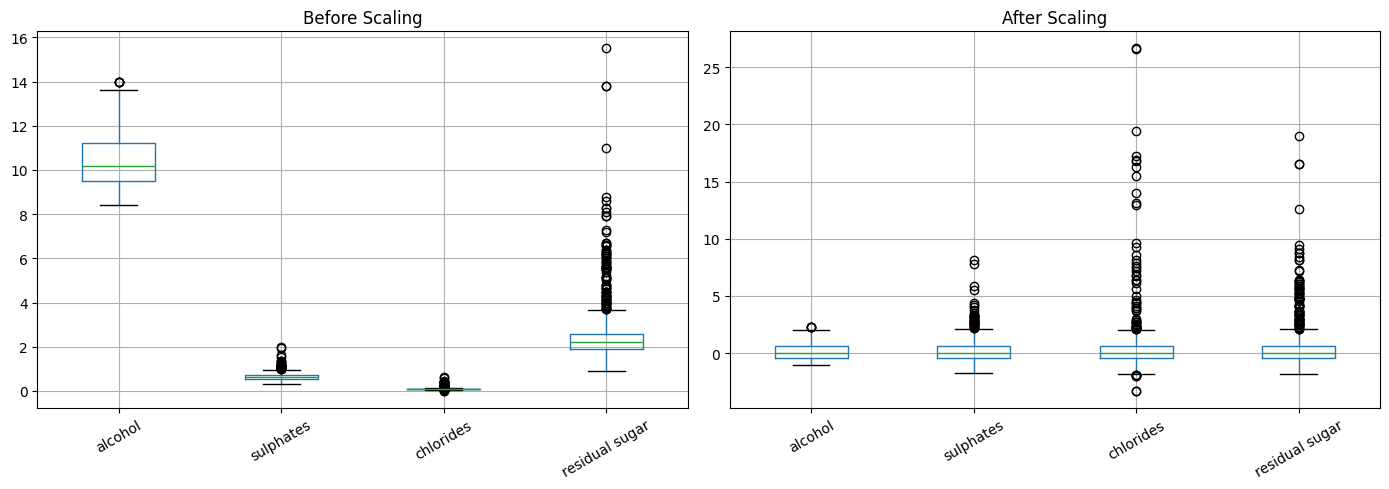

In [9]:
# ====================================================
# MODULE 4: BOXPLOT COMPARISON (Outlier Visibility)
# ====================================================

features_to_check = ['alcohol', 'sulphates', 'chlorides', 'residual sugar']

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Before Scaling 
X_train[features_to_check].boxplot(ax=axes[0])
axes[0].set_title("Before Scaling")
axes[0].tick_params(axis='x', rotation=30)

# After Scaling 
X_train_scaled[features_to_check].boxplot(ax=axes[1])
axes[1].set_title("After Scaling")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Result Analysis: Boxplot Comparison — Before vs After Robust Scaling

**What the plot shows**

Boxplots of four features (`alcohol`, `sulphates`, `chlorides`, `residual sugar`) before and after `RobustScaler`, plotted on shared axes within each subplot.

**Observations**

- **Before scaling, the four features are visually incomparable.** `alcohol` sits around 8–14, `sulphates` and `chlorides` are compressed near the bottom (0–2 and 0–0.6 respectively), and `residual sugar` has a long tail of outliers stretching up to ~15.5. Because they're on completely different scales, you can't visually compare their relative spread or outlier severity on one shared axis — `sulphates` and `chlorides` look almost like flat lines next to `alcohol`.

- **After scaling, all four boxes are now centered at 0 and roughly comparable in IQR width.** This is the median-centering property confirmed visually — the green median line (before) and the box center (after) both land at 0 for every feature, matching what you already saw numerically in the `describe()` output.

- **Outliers remain fully visible as outliers — they are not compressed away.** This is the core point of this plot. Notice `chlorides` and `residual sugar` still show a clear cluster of circles (outlier points) extending well above their boxes, even after scaling — up to ~27 for `chlorides` and ~19 for `residual sugar`. `RobustScaler` makes no attempt to pull these into a bounded range; it deliberately leaves them stretched out, because the scaling factor (IQR) is computed only from the "normal" middle 50% of data, which the outliers don't influence.

- **Relative box sizes are now meaningful.** Before scaling, we couldn't tell whether `sulphates` or `chlorides` had a "wider" typical spread relative to their own outliers — the raw units made comparison meaningless. After scaling, you can see `alcohol`'s box (IQR) is proportionally the widest of the four relative to its whiskers, meaning it has the least extreme outlier behavior among these features, while `chlorides` and `residual sugar` show boxes that are small relative to their long outlier tails — meaning most of their data is tightly packed near the median, with a handful of values sitting very far out.

**Why this matters — contrast with what `MinMaxScaler` would do here**

- If these same four features were scaled with `MinMaxScaler` instead, `chlorides`' single max value (0.6 before scaling, or ~27 after — an extreme outlier) would become the scaler's `X_max`, and *every other* `chlorides` value would be compressed into a tiny sliver near 0. 

- We wouldn't see spread-out outlier dots like this — the box and whiskers would collapse to almost nothing on the left, with the true structure hidden. Here, RobustScaler keeps the "normal" data's box a *readable, comparable size* across features, while still honestly showing where the outliers are — it doesn't hide them, it just refuses to let them control the scale for everyone else.

**Conclusion**

This confirms `RobustScaler`'s defining behavior: median-centered, IQR-scaled, and **explicitly outlier-resistant** — outliers stay visible as outliers rather than distorting the scale for the rest of the data. This sets up the next comparison nicely: putting `MinMaxScaler` and `RobustScaler` head-to-head on the *same* outlier-injected dataset to make this difference undeniable.

In [10]:
# ==================================================
# MODULE 5: MinMaxScaler vs RobustScaler (Outliers)
# ==================================================

from sklearn.preprocessing import MinMaxScaler, RobustScaler

# Adding the  synthetic outliers 
outliers = pd.DataFrame({
    'fixed acidity': [19.0, 18.5, 20.0],
    'volatile acidity': [2.0, 2.1, 1.8],
    'citric acid': [1.5, 1.6, 1.4],
    'residual sugar': [25.0, 30.0, 20.0],
    'chlorides': [0.9, 1.0, 0.8],
    'free sulfur dioxide': [120, 150, 100],
    'total sulfur dioxide': [400, 450, 350],
    'density': [1.005, 1.010, 1.002],
    'pH': [4.5, 4.6, 4.4],
    'sulphates': [3.0, 3.5, 2.8],
    'alcohol': [18.0, 17.5, 19.0]
})

df_outliers = pd.concat([df, outliers], ignore_index=True)

X_out = df_outliers.drop('quality', axis=1)
y_out = df_outliers['quality']

X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(
    X_out, y_out, test_size=0.2, random_state=42
)

# Fit both scalers on the same outlier-contaminated training data
minmax = MinMaxScaler()
robust = RobustScaler()

X_train_minmax = pd.DataFrame(minmax.fit_transform(X_train_out), columns=X_train_out.columns)
X_train_robust = pd.DataFrame(robust.fit_transform(X_train_out), columns=X_train_out.columns)

In [11]:
# ==================================================
# MODULE 5: MinMaxScaler vs RobustScaler (Outliers)
# ==================================================

from sklearn.preprocessing import MinMaxScaler, RobustScaler

# Adding the  synthetic outliers 
outliers = pd.DataFrame({
    'fixed acidity': [19.0, 18.5, 20.0],
    'volatile acidity': [2.0, 2.1, 1.8],
    'citric acid': [1.5, 1.6, 1.4],
    'residual sugar': [25.0, 30.0, 20.0],
    'chlorides': [0.9, 1.0, 0.8],
    'free sulfur dioxide': [120, 150, 100],
    'total sulfur dioxide': [400, 450, 350],
    'density': [1.005, 1.010, 1.002],
    'pH': [4.5, 4.6, 4.4],
    'sulphates': [3.0, 3.5, 2.8],
    'alcohol': [18.0, 17.5, 19.0]
})

# Merge outliers in df
df_outliers = pd.concat([df, outliers], ignore_index=True)

# Extract features and target columns
X_out = df_outliers.drop('quality', axis=1)
y_out = df_outliers['quality']

# Split the dataset into new train/test
X_train_out, X_test_out, y_train_out, y_test_out = train_test_split(
    X_out, y_out, test_size=0.2, random_state=42
    )

# Fit both Scalers on the same outlier-contaminated training data
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

X_train_minmax = pd.DataFrame(minmax_scaler.fit_transform(X_train_out), columns=X_train_out.columns)
X_train_robust = pd.DataFrame(robust_scaler.fit_transform(X_train_out), columns=X_train_out.columns)



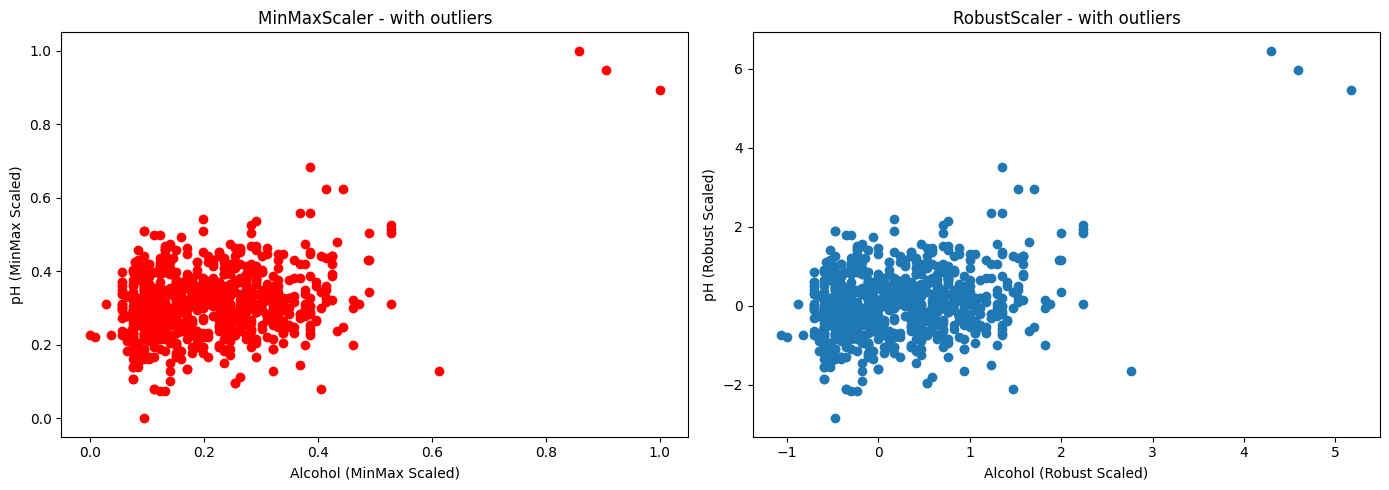

In [12]:

# Visual comparison : Alcohol vs pH , on same outlier data

fig, (axis1, axis2) = plt.subplots(1,2, figsize=(14,5))

axis1.scatter(X_train_minmax['alcohol'], X_train_minmax['pH'], color='red')
axis1.set_xlabel("Alcohol (MinMax Scaled)")
axis1.set_ylabel("pH (MinMax Scaled)")
axis1.set_title("MinMaxScaler - with outliers")

axis2.scatter(X_train_robust['alcohol'], X_train_robust['pH'])
axis2.set_xlabel("Alcohol (Robust Scaled)")
axis2.set_ylabel("pH (Robust Scaled)")
axis2.set_title("RobustScaler - with outliers")

plt.tight_layout()
plt.show()

## Result Analysis: MinMaxScaler vs RobustScaler — Head-to-Head on Outlier Data

**What the plot shows**

The same outlier-contaminated `alcohol` vs `pH` data, scaled independently by `MinMaxScaler` (left) and `RobustScaler` (right), plotted on their own axes.

**Observations**

- **MinMaxScaler (left): the "normal" cluster is crushed into a narrow band.** The bulk of the data — hundreds of real wine samples — is squeezed into roughly the 0.0–0.6 range on both axes, with most points overlapping heavily near 0.2–0.4. The 3 injected outliers sit isolated near (0.9–1.0, 0.9–1.0), having single-handedly defined the top of the scale. A distance-based model looking at this plot would see the 3 outliers as "far away" and struggle to distinguish meaningful differences among the hundreds of normal points crammed into the bottom-left.

- **RobustScaler (right): the normal cluster stays spread out and readable.** The same hundreds of normal points now occupy a much wider, more usable range (roughly -2 to +2 on both axes), with visible internal structure — you can actually see density variation, clusters, and spread among the normal data. The 3 outliers are still clearly visible on the right and top of the plot (alcohol ~4.3–5.2, pH ~5.3–6.4), sitting far from the main cluster — but critically, **they don't compress everyone else** to do so.

- **Axis scale interpretation differs meaningfully.** On the MinMax plot, "0.6" is close to the maximum meaningful value — most information lives in 0–0.4. On the Robust plot, values like -2 to 2 represent roughly the typical (non-outlier) spread of the data in IQR units, and the outliers extending to 5–6 are honestly reported as being several IQRs away from the median — which is arguably a more statistically meaningful way to describe "how extreme" a point is.

- **Same 3 outliers, same underlying data — only the scaler differs.** This isolates the scaler as the sole variable, which makes the comparison rigorous: any difference in how "usable" the normal data looks is attributable purely to the median/IQR vs min/max scaling logic, not to any other change in the pipeline.

**Conclusion**

- This is the clearest possible demonstration of why scaler choice matters when outliers are present. `MinMaxScaler` is defined entirely by its two most extreme points, so a handful of outliers can silently destroy the usable resolution of the rest of the dataset.

- `RobustScaler`, by scaling around the median and IQR, keeps the majority of the data in a well-spread, interpretable range while still preserving outliers as visibly distinct points — rather than letting them dictate the scale for everyone else. 

- For datasets where outliers are expected but shouldn't be discarded (e.g., real sensor or survey data), `RobustScaler` is the safer default over `MinMaxScaler`.